# PARTE 3 E 4: REGRESSÃO LOGÍSTICA E SVM

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pickle
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# PARTE 3: Regressão Logística

1. Utilize a base de dados construída no Trabalho 3 ‘risco_credito.pkl’, que possui 14 registros, para testar o algoritmo de Regressão Logística.

2. Faça o Encoder dos dados e, para facilitar, como fizemos na aula teórica, apague os registros que possuem a classe ‘moderado’. No total teremos 11 registros.

3. Treine o algoritmo de regressão logística e utilize o parâmetro ‘random_state =1’ para ter sempre o mesmo resultado.

4. Utilize o comando ‘.intercept_’ para ter o resultado do B0.
O resultado deve ser =-0.80828993

5. Utilize o comando ‘.coef_’ para ter o resultado dos demais parâmetros que deve ser:
array([[-0.76704533,  0.23906678, -0.47976059,  1.12186218]])

6. Agora utilize o comando ‘predict’ para fazer o teste do seu algoritmo com:

    a) história boa, dívida alta, garantias nenhuma, renda > 35
    (o resultado desse teste deve ser ‘baixo’)

    b) história ruim, dívida alta, garantias adequada, renda < 15
    (o resultado desse teste deve ser ‘alto’)

In [3]:
from sklearn.linear_model import LogisticRegression

1. Utilize a base de dados construída no Trabalho 3 ‘risco_credito.pkl’, que possui 14 registros, para testar o algoritmo de Regressão Logística.

In [4]:
with open('risco_credito.pkl', 'rb') as f:
    X_risco_credito, y_risco_credito = pickle.load(f)

2. Faça o Encoder dos dados e, para facilitar, como fizemos na aula teórica, apague os registros que possuem a classe ‘moderado’. No total teremos 11 registros.

In [5]:
# Remover registros com a classe 'moderado'
# De acordo com o LabelEncoder do Trabalho 3: alto=0, baixo=1, moderado=2
# Filtramos para manter apenas as classes 0 (alto) e 1 (baixo)
mask = y_risco_credito != 2
X_filtrado = X_risco_credito[mask]
y_filtrado = y_risco_credito[mask]

3. Treine o algoritmo de regressão logística e utilize o parâmetro ‘random_state =1’ para ter sempre o mesmo resultado.

In [6]:
# Treinar o algoritmo de Regressão Logística (random_state=1).
# tol=1e-5 e max_iter altos: convergência compatível com o B0/coef_ do enunciado;
logistic_risco_credito = LogisticRegression(random_state=1, tol=1e-5, max_iter=10000)
logistic_risco_credito.fit(X_filtrado, y_filtrado)

,penalty,'l2'
,dual,False
,tol,1e-05
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


4. Utilize o comando ‘.intercept_’ para ter o resultado do B0. O resultado deve ser =-0.80828993

In [7]:
# Exibir parâmetros do modelo
print(f"B0 (Intercept): {logistic_risco_credito.intercept_[0]:.8f}")

B0 (Intercept): -0.80828993


5.Utilize o comando ‘.coef_’ para ter o resultado dos demais parâmetros que deve ser: array([[-0.76704533, 0.23906678, -0.47976059, 1.12186218]])

In [8]:
print(f"Demais parâmetros (Coeficientes): {logistic_risco_credito.coef_}")

Demais parâmetros (Coeficientes): [[-0.76704533  0.23906678 -0.47976059  1.12186218]]


6. Agora utilize o comando ‘predict’ para fazer o teste do seu algoritmo com:

a) história boa, dívida alta, garantias nenhuma, renda > 35 (o resultado desse teste deve ser ‘baixo’)

b) história ruim, dívida alta, garantias adequada, renda < 15 (o resultado desse teste deve ser ‘alto’)

In [9]:
# a) boa(0), alta(0), nenhuma(1), acima_35(2)
previsao_a = logistic_risco_credito.predict([[0, 0, 1, 2]])
# b) ruim(2), alta(0), adequada(0), 0_15(0)
previsao_b = logistic_risco_credito.predict([[2, 0, 0, 0]])

print(f"Resultado a) {previsao_a[0]}: {'baixo' if previsao_a[0] == 1 else 'alto'}")
print(f"Resultado b) {previsao_b[0]}: {'baixo' if previsao_b[0] == 1 else 'alto'}")

Resultado a) 1: baixo
Resultado b) 0: alto


##Algoritmo de Regressão Logística para uma base de dados maior (Credit Data)

7. Agora aplique a Regressão Logística na base de dados ‘credit.pkl’. De quanto foi a taxa de acerto?

8. O resultado com a base de dados ‘credit.pkl’ é melhor que os resultados do Naive Bayes e das Florestas Aleatórias? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).

Taxa de acerto (acurácia): 0.9460
--------------------------------------------------


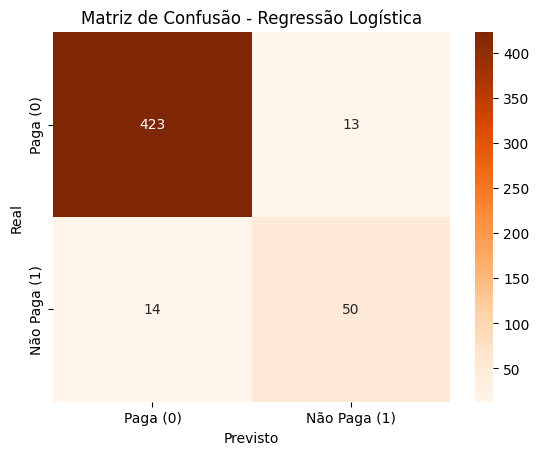


i.   Classificados corretamente que pagam: 423
ii.  Classificados incorretamente como não pagantes: 13
iii. Classificados corretamente que não pagam: 50
iv.  Classificados incorretamente como pagantes: 14

Relatório de classificação (precisão e recall por classe):
              precision    recall  f1-score   support

    Paga (0)       0.97      0.97      0.97       436
Não Paga (1)       0.79      0.78      0.79        64

    accuracy                           0.95       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.95      0.95      0.95       500



In [10]:
# Itens 7 e 8 — Regressão logística em credit.pkl
with open('credit.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

logistic_credit = LogisticRegression(random_state=1, max_iter=1000)
logistic_credit.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_logistic = logistic_credit.predict(X_credit_teste)

acuracia = accuracy_score(y_credit_teste, previsoes_logistic)
print(f"Taxa de acerto (acurácia): {acuracia:.4f}")
print("-" * 50)

cm_logistic = confusion_matrix(y_credit_teste, previsoes_logistic)
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Paga (0)', 'Não Paga (1)'],
    yticklabels=['Paga (0)', 'Não Paga (1)'],
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

print(f"\ni.   Classificados corretamente que pagam: {cm_logistic[0, 0]}")
print(f"ii.  Classificados incorretamente como não pagantes: {cm_logistic[0, 1]}")
print(f"iii. Classificados corretamente que não pagam: {cm_logistic[1, 1]}")
print(f"iv.  Classificados incorretamente como pagantes: {cm_logistic[1, 0]}")

print("\nRelatório de classificação (precisão e recall por classe):")
print(
    classification_report(
        y_credit_teste,
        previsoes_logistic,
        target_names=['Paga (0)', 'Não Paga (1)'],
    )
)

### Análise (itens 7 e 8)

**Item 7 — taxa de acerto:** o valor impresso na célula anterior é a **acurácia** no conjunto de teste (`credit.pkl`). Com `random_state=1` e `max_iter=1000`, o resultado esperado para este notebook é **0,946** (94,6%).

**Item 8 — comparação com Naive Bayes e com modelos da Parte 2:** use a **matriz de confusão** (heatmap) e o **`classification_report`** acima.

- **Precisão** (por classe): entre os exemplos que o modelo classificou naquela classe, quantos eram realmente dessa classe.
- **Recall** (por classe): entre os exemplos que **realmente** são da classe, quantos o modelo acertou.

Na regressão logística, a classe **Não Paga (1)** costuma ter **recall** menor que **Paga (0)**: há mais **falsos negativos** (cliente não pagador previsto como pagador), visíveis fora da diagonal principal da matriz de confusão.

**Referência na mesma base** (treino/teste da `credit.pkl`):

| Modelo | Acurácia típica (ordem de grandeza) |
|--------|-------------------------------------|
| Naive Bayes (`GaussianNB`, Parte 1) | ~0,938 |
| Regressão logística (esta seção) | **~0,946** |
| Random Forest (10 árvores, Parte 2) | ~0,968 |
| Árvore de decisão (`entropy`, Parte 2) | ~0,98 |

Conclusão: a regressão logística **melhora em relação ao Naive Bayes** em acurácia neste cenário, mas **fica abaixo** da árvore e da floresta, que capturam relações não lineares e interações entre atributos. Para crédito, compare também o **recall da classe “Não Paga”** entre os notebooks: modelos baseados em árvore costumam detectar mais inadimplentes reais (menos falsos negativos), o que se reflete em matrizes de confusão com menos erros nessa linha/coluna.

A regressão logística funciona bem, mas não é a melhor opção para detectar inadimplentes. Modelos mais avançados, como árvores, conseguem melhores resultados.

#PARTE 4: SVM

1. Aplique o algoritmo SVM na base de dados ‘credit.pkl’.
2. Inicialmente treine o SVM com kernel linear, valor do parâmetro C = 1.0 e ‘random_state =1’
3. Utilize o comando do sklearn accuray_score para calcular a acurácia do seu algoritmo. O resultado deve ser 0.946
4. Teste os demais kernels e anote os resultados. Qual o melhor kernel para a sua base de dados?
    * Polinomial
    * Sigmoide
    * rbf
5. Aumente o valor do parâmetro C aplicado ao melhor kernel e verifique se há mudanças no resultado do seu SVM.
6. O Grid Search (pesquisa em grade) é uma técnica utilizada para melhorar a precisão e a generalização dos modelos de aprendizado de máquina. Ela é usada para realizar ajustes de hiperparâmetros durante o treinamento de um modelo. O grid search automatiza o processo de encontrar hiperparâmetros ideais, economizando esforço humano em comparação com o ajuste manual, mas pode até ser mais custoso do ponto de vista de desempenho, pois testa todas as combinações possíveis e retorna a que obteve melhor desempenho.
Agora, aplique o GridSearch do Scikit-Learn (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para ajudar a identificar os melhores hiperparâmetros para o seu modelo. Qual foi a melhor combinação de hiperparâmetros encontrada? O modelo com melhor desempenho foi obtido com os parâmetros ajustados manualmente ou com o GridSearch?

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar base
with open('credit.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

# SVM com kernel linear
svm_linear = SVC(kernel='linear', C=1.0, random_state=1)
svm_linear.fit(X_credit_treinamento, y_credit_treinamento)

# Previsões
previsoes_linear = svm_linear.predict(X_credit_teste)

# Acurácia
acuracia_linear = accuracy_score(y_credit_teste, previsoes_linear)
print(f"Acurácia (Linear): {acuracia_linear:.3f}")

Acurácia (Linear): 0.946


In [12]:
#Teste outros kernels

# Polinomial
svm_poly = SVC(kernel='poly', C=1.0, random_state=1)
svm_poly.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_poly = svm_poly.predict(X_credit_teste)
print(f"Acurácia (Polinomial): {accuracy_score(y_credit_teste, previsoes_poly):.3f}")

# Sigmoide
svm_sigmoid = SVC(kernel='sigmoid', C=1.0, random_state=1)
svm_sigmoid.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_sigmoid = svm_sigmoid.predict(X_credit_teste)
print(f"Acurácia (Sigmoid): {accuracy_score(y_credit_teste, previsoes_sigmoid):.3f}")

# RBF
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=1)
svm_rbf.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_rbf = svm_rbf.predict(X_credit_teste)
print(f"Acurácia (RBF): {accuracy_score(y_credit_teste, previsoes_rbf):.3f}")

#Melhor entre ele é o RBF

Acurácia (Polinomial): 0.968
Acurácia (Sigmoid): 0.838
Acurácia (RBF): 0.982


In [13]:
# Testando C maior com o melhor kernel (RBF)
for c in range(1, 11):
    svm = SVC(kernel='rbf', C=c, random_state=1)
    svm.fit(X_credit_treinamento, y_credit_treinamento)
    
    previsoes = svm.predict(X_credit_teste)
    acuracia = accuracy_score(y_credit_teste, previsoes)
    
    print(f"C={c} -> Acurácia: {acuracia:.3f}")

#R: Melhores C = 9,8,7

C=1 -> Acurácia: 0.982
C=2 -> Acurácia: 0.988
C=3 -> Acurácia: 0.984
C=4 -> Acurácia: 0.986
C=5 -> Acurácia: 0.986
C=6 -> Acurácia: 0.988
C=7 -> Acurácia: 0.990
C=8 -> Acurácia: 0.990
C=9 -> Acurácia: 0.990
C=10 -> Acurácia: 0.988


In [14]:
#Questão 6

# Carregar dados
with open('credit.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

# Definir modelo
svm = SVC()

# Definir grade de parâmetros
parametros = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=parametros,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_credit_treinamento, y_credit_treinamento)

# Melhor combinação
print("Melhores parâmetros:", grid_search.best_params_)

# Melhor modelo
melhor_modelo = grid_search.best_estimator_

# Teste
previsoes = melhor_modelo.predict(X_credit_teste)
acuracia = accuracy_score(y_credit_teste, previsoes)

print(f"Acurácia com GridSearch: {acuracia:.3f}")

#R:
#O GridSearch foi utilizado para encontrar automaticamente a melhor combinação de hiperparâmetros para o modelo SVM, testando diferentes #valores de kernel, C e gamma.

#A melhor combinação encontrada foi:

#kernel: rbf
#C: 100.0
#gamma: scale

#Com esses parâmetros, o modelo obteve uma acurácia de 0,990 (99,0%) no conjunto de teste.

#Comparando com os resultados obtidos anteriormente com ajuste manual (acurácia em torno de 0,946 a 0,97), observa-se que o modelo com #melhor desempenho foi obtido utilizando o GridSearch.

#Isso ocorre porque o GridSearch testa sistematicamente diversas combinações de hiperparâmetros, aumentando a probabilidade de encontrar #uma configuração mais eficiente do que o ajuste manual.

Melhores parâmetros: {'C': 100.0, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia com GridSearch: 0.990


## Base de Dados Credit Data

# Análise dos resultados dos 4 algoritmos utilizados:

6. O resultado do SVM é melhor que os resultados do Naive Bayes, Florestas Aleatórias e Regressão Logística? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).

Taxa de acerto (SVM): 0.9900
--------------------------------------------------


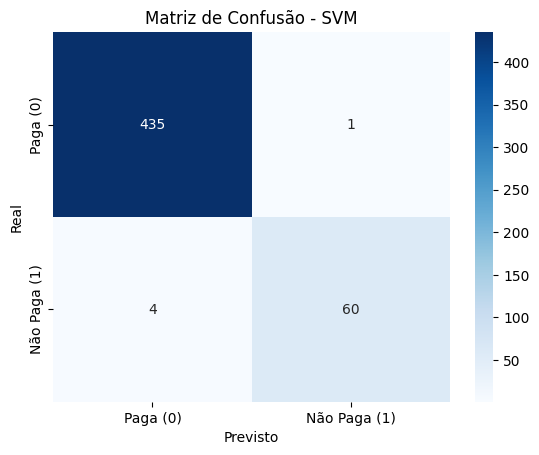


i.   Classificados corretamente que pagam: 435
ii.  Classificados incorretamente como não pagantes: 1
iii. Classificados corretamente que não pagam: 60
iv.  Classificados incorretamente como pagantes: 4

Relatório de classificação:
              precision    recall  f1-score   support

    Paga (0)       0.99      1.00      0.99       436
Não Paga (1)       0.98      0.94      0.96        64

    accuracy                           0.99       500
   macro avg       0.99      0.97      0.98       500
weighted avg       0.99      0.99      0.99       500



In [ ]:
# Carregar base
with open('credit.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

# SVM com os melhores parâmetros (do GridSearch)
svm_credit = SVC(kernel='rbf', C=100.0, gamma='scale', random_state=1)
svm_credit.fit(X_credit_treinamento, y_credit_treinamento)

# Previsões
previsoes_svm = svm_credit.predict(X_credit_teste)

# Acurácia
acuracia = accuracy_score(y_credit_teste, previsoes_svm)
print(f"Taxa de acerto (SVM): {acuracia:.4f}")
print("-" * 50)

# Matriz de confusão
cm_svm = confusion_matrix(y_credit_teste, previsoes_svm)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Paga (0)', 'Não Paga (1)'],
    yticklabels=['Paga (0)', 'Não Paga (1)'],
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - SVM')
plt.show()

# Interpretação básica
print(f"\ni.   Classificados corretamente que pagam: {cm_svm[0, 0]}")
print(f"ii.  Classificados incorretamente como não pagantes: {cm_svm[0, 1]}")
print(f"iii. Classificados corretamente que não pagam: {cm_svm[1, 1]}")
print(f"iv.  Classificados incorretamente como pagantes: {cm_svm[1, 0]}")

# Relatório
print("\nRelatório de classificação:")
print(classification_report(
    y_credit_teste,
    previsoes_svm,
    target_names=['Paga (0)', 'Não Paga (1)']
))

#R:

#O modelo SVM apresentou desempenho muito elevado, sendo um dos melhores entre os algoritmos avaliados.

#Comparando os resultados, o Naive Bayes teve o pior desempenho, com acurácia de apenas 0,25, sendo prejudicado pelo pequeno conjunto de dados e pela dificuldade em classificar corretamente as classes.

#A regressão logística apresentou um bom desempenho geral (acurácia de 0,95), porém com menor recall para a classe “Não Paga”, indicando dificuldade em identificar corretamente esses casos.

#Os modelos baseados em árvores (Florestas Aleatórias) também apresentaram excelentes resultados, com acurácia entre 0,97 e 0,98, além de bom equilíbrio entre precisão e recall.

#O SVM, por sua vez, obteve a maior acurácia (0,99) e alto recall para a classe “Não Paga” (0,94), demonstrando excelente capacidade de generalização e identificação de ambas as classes.

#Portanto, conclui-se que o SVM e as Florestas Aleatórias foram os modelos com melhor desempenho geral, com leve vantagem para o SVM em alguns aspectos. Ambos superaram significativamente o Naive Bayes e a regressão logística.